In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.risk.ttc import time_to_collision, post_encroachment_time
import numpy as np

# TEST 1: head-on, should collide (~4.05s)
ttc = time_to_collision((0,0), (1,0), (10,0), (-1,0))
print(f"Head-on TTC: {ttc:.2f} s   (expect ~4.05)")

# TEST 2: diverging (inf)
ttc = time_to_collision((0,0), (-1,0), (10,0), (1,0))
print(f"Diverging TTC: {ttc}   (expect inf)")

# TEST 3: parallel (inf)
ttc = time_to_collision((0,0), (1,0), (0,5), (1,0))
print(f"Parallel TTC: {ttc}   (expect inf)")

# TEST 4: overlapping (0.0)
ttc = time_to_collision((0,0), (0,0), (1,0), (0,0))
print(f"Overlapping TTC: {ttc}   (expect 0.0)")

# TEST 5: PET (2.0)
pet = post_encroachment_time([(0.0,5.0,0.0)], [(2.0,5.0,0.0)])
print(f"PET: {pet:.2f} s   (expect 2.0)")

Head-on TTC: 4.05 s   (expect ~4.05)
Diverging TTC: inf   (expect inf)
Parallel TTC: inf   (expect inf)
Overlapping TTC: 0.0   (expect 0.0)
PET: 2.00 s   (expect 2.0)


In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.simulator.scenario import Agent, simulate
from src.risk.ttc import time_to_collision
import numpy as np

# Forklift drives down the aisle: from (1.75, 0) to (1.75, 20), fast
forklift = Agent("F1", "forklift", [(1.75, 0), (1.75, 20)], speed=3.0, radius=1.5)

# Pedestrian walks across the aisle at y=10: from (0, 10) to (3.5, 10), slow
ped = Agent("P1", "person", [(0, 10), (3.5, 10)], speed=1.4, radius=0.4)

history = simulate([forklift, ped], duration=10, hz=10)

# At each timestep, compute TTC between the two agents
print("  t     forklift_y   ped_x    TTC")
for snap in history:
    f = next(s for s in snap if s["id"] == "F1")
    p = next(s for s in snap if s["id"] == "P1")
    ttc = time_to_collision((f["x"], f["y"]), (f["vx"], f["vy"]),
                            (p["x"], p["y"]), (p["vx"], p["vy"]),
                            radius_a=f["radius"], radius_b=p["radius"])
    ttc_str = f"{ttc:.2f}" if ttc != np.inf else "inf"
    print(f"{snap[0]['t']:5.1f}    {f['y']:6.2f}     {p['x']:5.2f}    {ttc_str}")

  t     forklift_y   ped_x    TTC
  0.0      0.30      0.14    inf
  0.1      0.60      0.28    inf
  0.2      0.90      0.42    inf
  0.3      1.20      0.56    inf
  0.4      1.50      0.70    inf
  0.5      1.80      0.84    inf
  0.6      2.10      0.98    inf
  0.7      2.40      1.12    inf
  0.8      2.70      1.26    inf
  0.9      3.00      1.40    inf
  1.0      3.30      1.54    inf
  1.1      3.60      1.68    inf
  1.2      3.90      1.82    inf
  1.3      4.20      1.96    inf
  1.4      4.50      2.10    inf
  1.5      4.80      2.24    inf
  1.6      5.10      2.38    inf
  1.7      5.40      2.52    inf
  1.8      5.70      2.66    inf
  1.9      6.00      2.80    inf
  2.0      6.30      2.94    inf
  2.1      6.60      3.08    inf
  2.2      6.90      3.22    inf
  2.3      7.20      3.36    inf
  2.4      7.50      3.50    0.59
  2.5      7.80      3.50    0.49
  2.6      8.10      3.50    0.39
  2.7      8.40      3.50    0.29
  2.8      8.70      3.50    0.19
  2.

In [ ]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.simulator.scenario import Agent, simulate
from src.risk.ttc import time_to_collision
import numpy as np

# Forklift drives down the aisle: from (1.75, 0) to (1.75, 20), fast
forklift = Agent("F1", "forklift", [(1.75, 0), (1.75, 20)], speed=3.0, radius=1.5)

# Pedestrian walks across the aisle at y=10: from (0, 10) to (3.5, 10), slow
ped = Agent("P1", "person", [(0, 10), (3.5, 10)], speed=1.4, radius=0.4)

history = simulate([forklift, ped], duration=10, hz=10)

# At each timestep, compute the  TTC between the two agents
print("  t     forklift_y   ped_x    TTC")
for snap in history:
    f = next(s for s in snap if s["id"] == "F1")
    p = next(s for s in snap if s["id"] == "P1")
    ttc = time_to_collision((f["x"], f["y"]), (f["vx"], f["vy"]),
                            (p["x"], p["y"]), (p["vx"], p["vy"]),
                            radius_a=f["radius"], radius_b=p["radius"])
    ttc_str = f"{ttc:.2f}" if ttc != np.inf else "inf"
    print(f"{snap[0]['t']:5.1f}    {f['y']:6.2f}     {p['x']:5.2f}    {ttc_str}")

  t     forklift_y   ped_x    TTC
  0.0      0.30      0.14    inf
  0.1      0.60      0.28    inf
  0.2      0.90      0.42    inf
  0.3      1.20      0.56    inf
  0.4      1.50      0.70    inf
  0.5      1.80      0.84    inf
  0.6      2.10      0.98    inf
  0.7      2.40      1.12    inf
  0.8      2.70      1.26    inf
  0.9      3.00      1.40    inf
  1.0      3.30      1.54    inf
  1.1      3.60      1.68    inf
  1.2      3.90      1.82    inf
  1.3      4.20      1.96    inf
  1.4      4.50      2.10    inf
  1.5      4.80      2.24    inf
  1.6      5.10      2.38    inf
  1.7      5.40      2.52    inf
  1.8      5.70      2.66    inf
  1.9      6.00      2.80    inf
  2.0      6.30      2.94    inf
  2.1      6.60      3.08    inf
  2.2      6.90      3.22    inf
  2.3      7.20      3.36    inf
  2.4      7.50      3.50    0.59
  2.5      7.80      3.50    0.49
  2.6      8.10      3.50    0.39
  2.7      8.40      3.50    0.29
  2.8      8.70      3.50    0.19
  2.

In [4]:
import numpy as np
from src.simulator.scenario import random_scenario, simulate, label_timestep
from collections import Counter

rng = np.random.default_rng(42)
label_counts = Counter()
n_scenarios = 200

for i in range(n_scenarios):
    force = (rng.random() < 0.25)   # only 25% forced-conflict (was 50%)
    agents = random_scenario(rng, force_conflict=force)
    history = simulate(agents, duration=8, hz=10)
    for snap in history:
        label, _ = label_timestep(snap)
        label_counts[label] += 1

total = sum(label_counts.values())
print("Label distribution across", n_scenarios, "scenarios:")
for lbl in ["SAFE", "CAUTION", "IMMINENT"]:
    c = label_counts[lbl]
    print(f"  {lbl:10s}: {c:6d}  ({100*c/total:.1f}%)")

Label distribution across 200 scenarios:
  SAFE      :   9905  (61.9%)
  CAUTION   :   1614  (10.1%)
  IMMINENT  :   4481  (28.0%)


In [5]:
import numpy as np
from src.simulator.scenario import random_scenario, simulate, label_timestep

rng = np.random.default_rng(7)
agents = random_scenario(rng, force_conflict=True)

print("Agents:")
for a in agents:
    print(f"  {a.id} ({a.cls}): start={a.waypoints[0]}, end={a.waypoints[-1]}, speed={a.speed:.1f}")

history = simulate(agents, duration=8, hz=10)

print("\n t    min_dist  min_ttc   label")
for snap in history[::5]:   # every 0.5s
    label, ttc = label_timestep(snap)
    persons = [s for s in snap if s["cls"]=="person"]
    forklifts = [s for s in snap if s["cls"]=="forklift"]
    md = min(np.hypot(f["x"]-p["x"], f["y"]-p["y"]) for p in persons for f in forklifts)
    ttc_s = f"{ttc:.2f}" if ttc != np.inf else "inf"
    print(f"{snap[0]['t']:4.1f}   {md:6.2f}    {ttc_s:>6}   {label}")

Agents:
  F0 (forklift): start=[ 2.06273867 20.        ], end=[2.06273867 0.        ], speed=3.6
  P0 (person): start=[-0.5         8.40133028], end=[4.         8.40133028], speed=1.5
  P1 (person): start=[ 2.87429946 15.94138858], end=[1.63777233 6.06064854], speed=1.2

 t    min_dist  min_ttc   label
 0.0     3.90      0.85   IMMINENT
 0.5     2.72      0.35   IMMINENT
 1.0     1.57      0.00   IMMINENT
 1.5     0.62      0.00   IMMINENT
 2.0     1.09      0.00   IMMINENT
 2.5     2.21       inf   SAFE
 3.0     2.02       inf   SAFE
 3.5     2.27       inf   SAFE
 4.0     3.54       inf   SAFE
 4.5     5.12       inf   SAFE
 5.0     6.80       inf   SAFE
 5.5     8.51       inf   SAFE
 6.0     8.62      6.26   SAFE
 6.5     8.30      5.76   SAFE
 7.0     7.72      5.26   SAFE
 7.5     7.15      4.76   SAFE


In [8]:
import numpy as np
import pandas as pd
from pathlib import Path
from src.simulator.scenario import random_scenario, simulate, label_timestep

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
rng = np.random.default_rng(123)

N_SCENARIOS = 2000
rows = []

for scen_id in range(N_SCENARIOS):
    force = (rng.random() < 0.5)
    agents = random_scenario(rng, force_conflict=force)
    history = simulate(agents, duration=8, hz=10)
    for snap in history:
        label, ttc = label_timestep(snap)
        for a in snap:
            rows.append({
                "scenario": scen_id,
                "t": a["t"],
                "agent_id": a["id"],
                "cls": a["cls"],
                "x": round(a["x"], 3),
                "y": round(a["y"], 3),
                "vx": round(a["vx"], 3),
                "vy": round(a["vy"], 3),
                "label": label,
                "min_ttc": round(ttc, 3) if ttc != np.inf else -1,
            })

df = pd.DataFrame(rows)
out = ROOT / "data/simulated/scenarios.csv"
out.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out, index=False)

print(f"Saved {len(df)} rows from {N_SCENARIOS} scenarios to {out}")
print("\nLabel distribution:")
print(df.groupby("label").size())

Saved 400160 rows from 2000 scenarios to /Users/aayushaswal/aisleguard/data/simulated/scenarios.csv

Label distribution:
label
CAUTION      43265
IMMINENT    111958
SAFE        244937
dtype: int64


In [11]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.bev.rasteriser import rasterise
import numpy as np

# a hand-made snapshot: pedestrian mid-aisle, forklift below it
snapshot = [
    {"cls": "person",   "x": 1.75, "y": 10.0, "vx": 1.4, "vy": 0.0},
    {"cls": "forklift", "x": 1.75, "y": 5.0,  "vx": 0.0, "vy": 3.0},
]

r = rasterise(snapshot)
print("Raster shape:", r.shape)   # expect (6, 64, 64)

# where did the pedestrian land? (channel 0 = ped occupancy)
py, px = np.where(r[0] > 0)
print(f"Pedestrian cell: col={px[0]}, row={py[0]}  (expect col~32, row~32)")

# where did the forklift land? (channel 1)
fy, fx = np.where(r[1] > 0)
print(f"Forklift cell:   col={fx[0]}, row={fy[0]}  (expect col~32, row~16)")

# check velocity channels carry the right values
print(f"Ped vx at its cell: {r[2, py[0], px[0]]}  (expect 1.4)")
print(f"Fork vy at its cell: {r[5, fy[0], fx[0]]}  (expect 3.0)")

Raster shape: (6, 64, 64)
Pedestrian cell: col=32, row=32  (expect col~32, row~32)
Forklift cell:   col=32, row=16  (expect col~32, row~16)
Ped vx at its cell: 1.399999976158142  (expect 1.4)
Fork vy at its cell: 3.0  (expect 3.0)


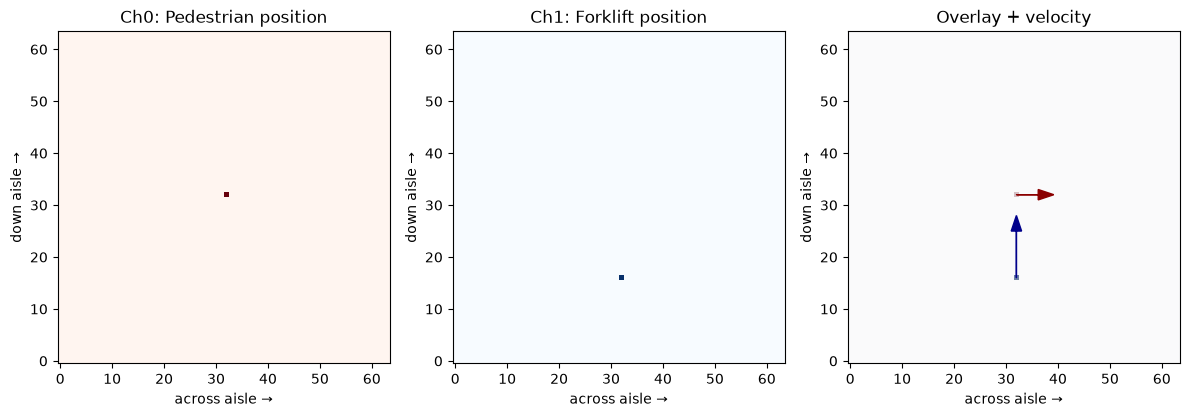

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Channel 0: pedestrian occupancy
axes[0].imshow(r[0], origin="lower", cmap="Reds")
axes[0].set_title("Ch0: Pedestrian position")

# Channel 1: forklift occupancy
axes[1].imshow(r[1], origin="lower", cmap="Blues")
axes[1].set_title("Ch1: Forklift position")

# Both overlaid, with velocity arrows
axes[2].imshow(r[0], origin="lower", cmap="Reds", alpha=0.6)
axes[2].imshow(r[1], origin="lower", cmap="Blues", alpha=0.6)
# draw velocity arrows
py, px = np.where(r[0] > 0)
axes[2].arrow(px[0], py[0], r[2,py[0],px[0]]*3, r[3,py[0],px[0]]*3,
              head_width=2, color="darkred")
fy, fx = np.where(r[1] > 0)
axes[2].arrow(fx[0], fy[0], r[4,fy[0],fx[0]]*3, r[5,fy[0],fx[0]]*3,
              head_width=2, color="darkblue")
axes[2].set_title("Overlay + velocity")

for ax in axes:
    ax.set_xlabel("across aisle →")
    ax.set_ylabel("down aisle →")

plt.tight_layout()
plt.savefig(ROOT / "outputs/bev_example.png", dpi=100)
plt.show()

In [13]:
import pandas as pd
import numpy as np
from pathlib import Path
from src.bev.rasteriser import rasterise

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(ROOT / "data/simulated/scenarios.csv")

LABEL_MAP = {"SAFE": 0, "CAUTION": 1, "IMMINENT": 2}

X = []   # rasters
y = []   # labels

# group by each unique scene (one scenario at one timestep)
grouped = df.groupby(["scenario", "t"])
print(f"Total scenes to rasterise: {grouped.ngroups}")

for (scen, t), scene in grouped:
    snapshot = [
        {"cls": row["cls"], "x": row["x"], "y": row["y"],
         "vx": row["vx"], "vy": row["vy"]}
        for _, row in scene.iterrows()
    ]
    raster = rasterise(snapshot)
    label = LABEL_MAP[scene["label"].iloc[0]]   # all agents in a scene share the label
    X.append(raster)
    y.append(label)

X = np.array(X, dtype=np.float32)   # (N, 6, 64, 64)
y = np.array(y, dtype=np.int64)     # (N,)

print(f"\nDataset ready: X={X.shape}, y={y.shape}")
print(f"Label counts: SAFE={np.sum(y==0)}, CAUTION={np.sum(y==1)}, IMMINENT={np.sum(y==2)}")

# save as compressed npz for fast loading in Phase 8
np.savez_compressed(ROOT / "data/simulated/bev_dataset.npz", X=X, y=y)
print(f"Saved to bev_dataset.npz")

Total scenes to rasterise: 160000

Dataset ready: X=(160000, 6, 64, 64), y=(160000,)
Label counts: SAFE=101624, CAUTION=16666, IMMINENT=41710
Saved to bev_dataset.npz
